In [ ]:
from langchain_community.utilities.sql_database import SQLDatabase
import json
import re
from typing import List, Dict, Any, Literal, TypedDict, Optional, Tuple, Set
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.messages.tool import ToolCall
from langgraph.types import Command
from IPython.display import Image, display
import os
from langchain.callbacks.tracers import LangChainTracer
import torch
import uuid  # put this at the top of your file if not already imported
from math import ceil

load_dotenv("./.env")
os.environ["LANGSMITH_API_KEY"] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true"
# Create the tracer
tracer = LangChainTracer(project_name="slm_agent")

In [2]:
#Set up database
database_file_path = "./inventory.db"
db = SQLDatabase.from_uri(f"sqlite:///{database_file_path}")
print(db.dialect)
print(db.get_usable_table_names())
print(db.run("PRAGMA table_info(inventory);"))

sqlite
['inventory']
[(0, 'Date', 'TEXT', 0, None, 0), (1, 'Store_ID', 'TEXT', 0, None, 0), (2, 'Product_ID', 'TEXT', 0, None, 0), (3, 'Category', 'TEXT', 0, None, 0), (4, 'Region', 'TEXT', 0, None, 0), (5, 'Inventory_Level', 'INTEGER', 0, None, 0), (6, 'Units_Sold', 'INTEGER', 0, None, 0), (7, 'Units_Ordered', 'INTEGER', 0, None, 0), (8, 'Demand_Forecast', 'REAL', 0, None, 0), (9, 'Price', 'REAL', 0, None, 0), (10, 'Discount', 'REAL', 0, None, 0), (11, 'Weather_Condition', 'TEXT', 0, None, 0), (12, 'Holiday_Promotion', 'INTEGER', 0, None, 0), (13, 'Competitor_Pricing', 'REAL', 0, None, 0), (14, 'Seasonality', 'TEXT', 0, None, 0), (15, 'Lead_Time', 'INTEGER', 0, None, 0)]


In [3]:
from openai import OpenAI

client = OpenAI(base_url="http://localhost:8000/v1", api_key="not-needed")

In [25]:
from openai import OpenAI

client = OpenAI(base_url="http://localhost:8000/v1", api_key="not-needed")

stream = client.chat.completions.create(
    model="/models/Qwen3-4B",  # use the full ID
    messages=[
        {"role": "system", "content": "/no_think"},
        {"role": "user", "content": "What's the capital of France?"}
    ],
    max_tokens=1000,
    stream=True
)

# print(response.choices[0].message.content)
# Collect the streaming chunks
collected_content = ""
tool_calls = []

for chunk in stream:
    if chunk.choices[0].delta.content:
        # Print each chunk as it arrives
        content_chunk = chunk.choices[0].delta.content
        print(content_chunk, end='', flush=True)
        collected_content += content_chunk

    # Handle tool calls in streaming
    if chunk.choices[0].delta.tool_calls:
        for tool_call_chunk in chunk.choices[0].delta.tool_calls:
            # Tool calls might come in multiple chunks too
            print(f"\n🔧 Tool call detected: {tool_call_chunk}")
            tool_calls.append(tool_call_chunk)

<think>

</think>

The capital of France is **Paris**.

In [4]:
# Define SQL tools
def list_tables_tool() -> Dict[str, Any]:
    """
    Retrieve a schema and example rows of all usable tables in the database.
    """
    try:
        # Get all usable tables
        tables = db.get_usable_table_names()
        if not tables:
            return {"result": "No tables found in the database."}

        # Get schema info for all tables
        schema_info = db.get_table_info(tables)
        return {"result": schema_info}
    except Exception as e:
        return {"error": f"Error listing tables: {str(e)}"}


def query_checker_tool(query: str) -> Dict[str, Any]:
    """
    Validate the SQL query by running an EXPLAIN statement.
    """
    try:
        if not query or not isinstance(query, str):
            return {"error": "Invalid query: Query must be a non-empty string"}

        # Basic validation
        if ";" in query and not query.strip().endswith(";"):
            return {"error": "Invalid query: Multiple statements detected. Please submit a single SQL statement."}

        # Check for SQL injection attempts (simple check)
        if "--" in query or "/*" in query:
            return {"error": "Invalid query: Comment syntax detected. Please remove comments."}

        result = db.run(f"EXPLAIN {query}")
        return {"result": "Query is valid and can be executed safely."}
    except Exception as e:
        return {"error": f"Query validation failed: {str(e)}"}


def db_query_tool(query: str) -> Dict[str, Any]:
    """
    Execute a SQL query against the database and get back the result.
    If the query is not correct, an error message will be returned.
    Returns results with column names in JSON format.
    """
    try:
        if not query or not isinstance(query, str):
            return {"error": "Invalid query: Query must be a non-empty string"}

        # Basic validation
        if ";" in query and not query.strip().endswith(";"):
            return {"error": "Invalid query: Multiple statements detected. Please submit a single SQL statement."}
        if "--" in query or "/*" in query:
            return {"error": "Invalid query: Comment syntax detected. Please remove comments."}

        # 🛡️ SAFETY: Force a LIMIT if missing
        lowered_query = query.lower()
        limit_value = 40  # default limit
        if "limit" not in lowered_query and "select" in lowered_query:
            query = query.rstrip(";") + f" LIMIT {limit_value};"

        # Execute the query
        raw_result = db.run_no_throw(query)
        if raw_result is None:
            return {"error": "Query execution failed. Please check your syntax and try again."}

        # Handle raw_result as string (based on your debug output)
        if isinstance(raw_result, str):
            # Parse the string representation of tuples
            import re
            import ast

            # Extract column names from the query
            column_names = []
            match = re.search(r'SELECT\s+(.*?)\s+FROM', query, re.IGNORECASE | re.DOTALL)
            if match:
                select_part = match.group(1)
                # Split by commas, but be careful with function calls that contain commas
                columns = []
                bracket_level = 0
                current_column = ""

                for char in select_part:
                    if char == ',' and bracket_level == 0:
                        columns.append(current_column.strip())
                        current_column = ""
                    else:
                        if char == '(':
                            bracket_level += 1
                        elif char == ')':
                            bracket_level -= 1
                        current_column += char

                if current_column.strip():
                    columns.append(current_column.strip())

                # Process each column expression to get the final name
                for col in columns:
                    # Check for explicit AS
                    as_match = re.search(r'\bAS\s+([`"\'a-zA-Z0-9_]+)', col, re.IGNORECASE)
                    if as_match:
                        name = as_match.group(1).strip('`\'"')
                        column_names.append(name)
                    else:
                        # No explicit AS - take the last segment for qualified names
                        parts = col.strip().split('.')
                        name = parts[-1].strip()

                        # If it's a function call without AS, use the function name
                        if '(' in name:
                            func_match = re.search(r'([a-zA-Z0-9_]+)\s*\(', col, re.IGNORECASE)
                            if func_match:
                                name = func_match.group(1)
                            else:
                                name = re.sub(r'[^a-zA-Z0-9_]', '_', col.strip())

                        column_names.append(name)

            # Try to parse the string as Python literal (list of tuples)
            try:
                # Check if it starts with '[(' and ends with ')]'
                if raw_result.startswith('[') and raw_result.endswith(']'):
                    # Use ast.literal_eval to safely parse the string into Python objects
                    parsed_result = ast.literal_eval(raw_result)

                    # If we don't have column names from query, use default ones
                    if not column_names and parsed_result and isinstance(parsed_result[0], tuple):
                        if len(parsed_result[0]) == 6:  # If matches your example's column count
                            column_names = ["Product_ID", "Inventory_Level", "Units_Sold", "Units_Ordered", "Discount",
                                            "Holiday_Promotion"]
                        else:
                            column_names = [f"column_{i}" for i in range(len(parsed_result[0]))]

                    # Convert tuples to dictionaries with column names
                    result = []
                    for row in parsed_result:
                        row_dict = {}
                        for i, value in enumerate(row):
                            if i < len(column_names):
                                row_dict[column_names[i]] = value
                            else:
                                row_dict[f"column_{i}"] = value
                        result.append(row_dict)

                    # 📣 BONUS: Warn if we hit the limit - only for SELECT queries
                    if "select" in lowered_query and len(result) >= limit_value:
                        return {
                            "result": result,
                            "warning": f"⚠️ Your query returned {limit_value} rows (the maximum limit). "
                                       "Consider refining your WHERE clause or being more specific to avoid data cutoff."
                        }

                    return {"result": result}
                else:
                    # Not a list of tuples, just return the string
                    return {"result": raw_result}

            except (SyntaxError, ValueError) as e:
                # If parsing fails, just return the string as is
                print(f"Failed to parse result string: {e}")
                return {"result": raw_result}
        else:
            # Not a string, just return as is
            return {"result": raw_result}

    except Exception as e:
        print(f"Error in db_query_tool: {str(e)}")
        return {"error": f"Query execution error: {str(e)}"}


def get_function_by_name(name):
    if name == "list_tables_tool":
        return list_tables_tool
    if name == "query_checker_tool":
        return query_checker_tool
    if name == "db_query_tool":
        return db_query_tool
    return None


# Define the tools in the format Qwen2.5 expects
SQL_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "list_tables_tool",
            "description": "Retrieve the table schemas in the database and sample rows for each of the tables.",
            "parameters": {
                "type": "object",
                "properties": {}
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "query_checker_tool",
            "description": "Validate the SQL query for correctness before query execution.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {
                        "type": "string",
                        "description": "The SQL query to be validated."
                    }
                },
                "required": ["query"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "db_query_tool",
            "description": "Execute an SQL query on the database.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query": {
                        "type": "string",
                        "description": "The SQL query to be executed on the database."
                    }
                },
                "required": ["query"]
            }
        }
    }
]

sql_tools_by_name = {
    "list_tables_tool": list_tables_tool,
    "query_checker_tool": query_checker_tool,
    "db_query_tool": db_query_tool
}


In [5]:
# functions
def try_parse_tool_calls(message_dict: dict) -> AIMessage:
    """
    Extracts tool calls from an OpenAI-compatible response message dictionary (vLLM).
    """
    content = message_dict.get("content", "").replace("<think>", "").replace("</think>", "").strip()
    tool_calls_data = message_dict.get("tool_calls", [])

    tool_calls = []
    for i, tool_call in enumerate(tool_calls_data):
        call_id = tool_call.get("id", f"call_{i}")
        fn_data = tool_call.get("function", {})
        fn_name = fn_data.get("name", f"unknown_tool_{i}")
        try:
            fn_args = json.loads(fn_data.get("arguments", "{}"))
        except json.JSONDecodeError:
            fn_args = {"raw_arguments": fn_data.get("arguments", "")}

        tool_calls.append({
            "id": call_id,
            "name": fn_name,
            "args": fn_args
        })

    return AIMessage(content=content, tool_calls=tool_calls)


def safe_json_parse(raw_str: str) -> dict:
    """
    Extract and parse the first valid JSON object from a string.
    Assumes the string starts with '{"' and ends with '}' before any non-JSON content.
    """
    brace_count = 0
    start_index = None

    for i, char in enumerate(raw_str):
        if char == '{':
            if start_index is None:
                start_index = i
            brace_count += 1
        elif char == '}':
            brace_count -= 1
            if brace_count == 0 and start_index is not None:
                json_str = raw_str[start_index:i + 1]
                return json.loads(json_str)

    raise ValueError("Valid JSON object not found in string.")


class ExtendedMessagesState(MessagesState):
    sql_data: dict = {}


def build_agent(TOOLS, tools_by_name, agent):
    # LLM Call for LangGraph integration
    def llm_call(state: ExtendedMessagesState):
        """LLM decides whether to call a tool or not"""
        messages = state["messages"]

        last_message = messages[-1]
        # In the llm_call function

        tool_agent_map = {
            "get_inventory_data_tool": "inventory_management_agent",
            "get_sales_data_tool": "sales_analyst_agent",
        }

        # flagging whether is inventory or sales agent requesting data from the sql agent
        if isinstance(last_message, ToolMessage) and last_message.name in tool_agent_map:
            agent_name = agent
            try:
                tool_content = json.loads(last_message.content)
                instruction_text = tool_content.get("requested", last_message.content)
            except json.JSONDecodeError:
                instruction_text = last_message.content

            return {
                "messages": messages + [
                    AIMessage(
                        content=instruction_text,
                        additional_kwargs={"agent_name": agent_name, "request_data": True, }
                    )
                ]
            }
        # if last message is from db_query_tool, we just return the sql query result, no need to let the sql agent check
        if agent == 'sql_agent' and isinstance(last_message, ToolMessage) and last_message.name == 'db_query_tool':
            try:
                raw_content = last_message.content

                if isinstance(raw_content, str):
                    tool_result = safe_json_parse(raw_content)
                elif isinstance(raw_content, dict):
                    tool_result = raw_content
                else:
                    raise ValueError("Unexpected ToolMessage content type")

                if "error" not in tool_result:
                    # Safely convert result to a string for AIMessage
                    result_str = json.dumps(tool_result["result"], ensure_ascii=False)

                    # when the sql_query_result is empty
                    if result_str == '""':
                        result_str = json.dumps({"status": "no_data"}, ensure_ascii=False)

                    return {
                        "messages": messages + [
                            AIMessage(
                                content=result_str,
                                additional_kwargs={"agent_name": agent}
                            )
                        ]
                    }
            except Exception as e:
                print(f"Failed to parse db_query_tool result: {e}")

        # Convert LangGraph message format to the format expected by Qwen
        converted_messages = []
        for msg in messages:
            if isinstance(msg, SystemMessage):
                converted_messages.append({"role": "system", "content": msg.content})
            elif isinstance(msg, HumanMessage):
                converted_messages.append({"role": "user", "content": msg.content})
            elif isinstance(msg, AIMessage):
                if hasattr(msg, 'tool_calls') and msg.tool_calls:
                    converted_messages.append({
                        "role": "assistant",
                        "content": msg.content,
                        "tool_calls": [{
                            "id": tc.get("id", f"call_{i}"),
                            "type": "function",
                            "function": {
                                "name": tc["name"],
                                "arguments": json.dumps(tc["args"])  # Must be a JSON string
                            }
                        } for i, tc in enumerate(msg.tool_calls)]
                    })
                else:
                    converted_messages.append({"role": "assistant", "content": msg.content})
            elif isinstance(msg, ToolMessage):
                converted_messages.append({
                    "role": "tool",
                    "name": msg.name,
                    "content": msg.content,
                })

        max_tokens = 4000
        # if agent == "sql_agent":  #increase the output tokens for sql agent
        #     max_tokens = 10000
        # using vLLM
        response = client.chat.completions.create(
            model="/models/Qwen3-4B",
            messages=converted_messages,
            tools=TOOLS,
            tool_choice="auto",  # Let model decide if tool should be called
            max_tokens=max_tokens,
            temperature=0.7,
        )
        # Use the new parser
        ai_message = try_parse_tool_calls(response.choices[0].message.model_dump())

        return {"messages": [ai_message]}

    def process_tool_args(args, tool_results):
        """Process tool arguments, resolving any variable references."""
        if not isinstance(args, dict):
            return args

        processed_args = {}
        for key, value in args.items():
            if isinstance(value, str) and value.startswith("{{") and value.endswith("}}"):
                # This is a variable reference
                var_name = value[2:-2]  # Remove {{ and }}
                if var_name in tool_results:
                    processed_args[key] = tool_results[var_name]
                else:
                    # Try to handle tool_output_function_name_result pattern
                    parts = var_name.split('_')
                    if len(parts) >= 4 and parts[0] == "tool" and parts[1] == "output" and parts[-1] == "result":
                        tool_name = '_'.join(parts[2:-1])
                        if f"{tool_name}_result" in tool_results:
                            processed_args[key] = tool_results[f"{tool_name}_result"]
                        else:
                            # If we can't resolve, keep as is (will likely cause an error)
                            processed_args[key] = value
                    else:
                        processed_args[key] = value
            else:
                processed_args[key] = value
        return processed_args

    def tool_node(state: ExtendedMessagesState):
        """Performs the tool calls sequentially, resolving dependencies between them."""
        result = []
        tool_results = {}  # Store results for variable resolution

        for tool_call in state["messages"][-1].tool_calls:
            # Process args to resolve any variable references
            processed_args = process_tool_args(tool_call["args"], tool_results)

            # Execute the tool
            tool = tools_by_name[tool_call["name"]]
            if tool_call["name"] == "list_tables_tool":
                observation = tool()
            elif tool_call["name"] == "summarize_sales_tool":
                observation = tool(state)
            else:
                # For other tools that require the query parameter
                observation = tool(**processed_args)

            # Store the result for potential future use
            for key, value in observation.items():
                tool_results[f"{tool_call['name']}_{key}"] = value

            # Create tool message
            result.append(
                ToolMessage(
                    content=json.dumps(observation) + "/no_think",
                    tool_call_id=tool_call["id"],
                    name=tool_call["name"]
                )
            )

        return {"messages": result}

    # Conditional edge function
    def should_continue(state: ExtendedMessagesState) -> str:
        """Decide if we should continue the loop or stop"""
        messages = state["messages"]
        last_message = messages[-1]

        # If the LLM makes a tool call, then perform an action
        if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
            return "Tools"

        # Otherwise, we stop (reply to the user)
        return END

    # Build workflow
    agent_builder = StateGraph(ExtendedMessagesState)

    # Add nodes
    agent_builder.add_node("Agent", llm_call)
    agent_builder.add_node("Tools", tool_node)

    # Add edges to connect nodes
    agent_builder.add_edge(START, "Agent")
    agent_builder.add_conditional_edges(
        "Agent",
        should_continue,
        {
            "Tools": "Tools",
            END: END,
        },
    )
    agent_builder.add_edge("Tools", "Agent")

    # Compile the agent
    return agent_builder.compile()

In [6]:
""  # Compile the agent
sql_agent = build_agent(SQL_TOOLS, sql_tools_by_name, "sql_agent")

In [39]:
# Add a system message and a user message
messages = [
    SystemMessage(content="""
    You are an SQLite data retrieval specialist that returns exactly the data requested.

    Your ONLY purpose is to fetch raw data with ALL fields explicitly requested by the agent.

    Process:
    1. FIRST, extract and list all specific fields mentioned in the request (e.g., Units_Sold, Inventory_Level)
    2. MUST use list_tables_tool to identify which tables contain these fields
    3. Write a SELECT query that includes EVERY requested field and make sure you use the proper filtering or aggregation in order to reduce the size of the results.
    4. ALWAYS validate your query using `query_checker_tool`
    5. Execute the validated query using `db_query_tool`

    Response format:
    - Output the query result as a **JSON array of objects**, where each object is a row with keys matching the field names.
    - Each key must be the exact column name from the SELECT query.
    - DO NOT use Markdown tables or plain text. Return ONLY structured JSON.

    Critical rules:
    - NEVER omit any requested field.
    - If a field is requested but doesn't match schema exactly, find and use the closest valid column name.
    - If the request is time-specific (e.g., "end of January 2022"), filter by the exact date: `WHERE Date = 'YYYY-MM-DD'`.
    - Compute `Average_Units_Sold` as the average of daily `Units_Sold` over the previous month.
    - Use a JOIN between:
        - A subquery that gets `Inventory_Level` for each product from the last day of that month.
        - A subquery that calculates the average `Units_Sold` per product during that month.
    - DO NOT use AVG on a single date's data. That is incorrect.
    - If the Sales Analyst Agent asks for Units Sold/Revenue for one or more full months:
      1. ALWAYS use aggregation functions:
         * `SUM(Units_Sold) AS Units_Sold`
         * `SUM(Units_Sold * Price * (1 - Discount/100)) AS Revenue`
      2. Include these fields in your SELECT clause:
         * Required aggregated fields: `SUM(Units_Sold)`, `SUM(Units_Sold * Price * (1 - Discount/100))`
         * Required grouping fields: `Store_ID`, `Product_ID`
         * IMPORTANT: When multiple months are requested, ALWAYS include date information in your output
      3. For month-level breakdown, extract the month from Date:
         * `strftime('%Y-%m', Date) AS Month`
      4. ALWAYS include a GROUP BY clause with appropriate dimensions:
         * Example: `GROUP BY Store_ID, Product_ID, strftime('%Y-%m', Date)` for store/product/month
         * Example: `GROUP BY strftime('%Y-%m', Date)` if only month-level data is requested
      5. Example of a correct query with month-level breakdown:
        instruction from another agent: Get total revenue and units sold for Store S004 for Feb 2022.
         ```sql
            SELECT
              Store_ID,
              Product_ID,
              strftime('%Y-%m', Date) AS Month,
              SUM(Units_Sold) AS Units_Sold,
              SUM(Units_Sold * Price * (1 - Discount/100)) AS Revenue
            FROM inventory
            WHERE Store_ID = 'S004'
              AND (
                Date BETWEEN '2022-01-01' AND '2022-01-31'
                OR Date BETWEEN '2022-02-01' AND '2022-02-28'
              )
            GROUP BY Store_ID, Product_ID, strftime('%Y-%m', Date);
         ```
    - If the Inventory Management Agent requests inventory data that includes `Average_Units_Sold`:
      1. **`Average_Units_Sold`** should be computed as the **average of daily `Units_Sold` values** for each product over the **previous month**.
      2. The query must also include the product’s `Inventory_Level` from the **last day of that month**.
      3. Use a **JOIN** between:
         - A subquery for the latest inventory data (`Inventory_Level`) on the **last day of the month**.
         - A subquery that calculates the **monthly average of daily `Units_Sold`** for each product.
      4. MUST refer to this example:
      ```sql
        SELECT current.Product_ID,
               current.Inventory_Level,
               avg_data.Average_Units_Sold
        FROM
            (SELECT Product_ID, Inventory_Level
             FROM inventory
             WHERE Store_ID = '{store_id}' AND Date = '{last_day_of_month}') AS current
        JOIN
            (SELECT Product_ID, AVG(Units_Sold) AS Average_Units_Sold
             FROM inventory
             WHERE Store_ID = '{store_id}' AND Date BETWEEN '{start_of_month}' AND '{last_day_of_month}'
             GROUP BY Product_ID) AS avg_data
        ON current.Product_ID = avg_data.Product_ID;
      ```

    Checklist before final output:
    ✅ Query includes ALL requested fields
    ✅ Revenue is computed correctly using the formula
    ✅ Aggregation is used for monthly totals if required
    ✅ Date filter uses exact last-day-of-month values
    ✅ Query is validated
    ✅ Output is structured JSON with no markdown or commentary
    ✅ If the query returns no rows, return a structured JSON with status "no_data" and a clear message (not an empty list)

    /no_think
    """),

    # HumanMessage(content="What are the total sales for toys category inside store S001 in the month of January 2022?")
    HumanMessage(
        content="Can you help me create the restock plan for Store S001 at the end of February 2022, and also the sales analysis on the same month?/no_think"),
    AIMessage(
        content="""from inventory_management_agent:  {"status": "waiting_for_sql_agent_response", "requested": "Retrieve inventory data for store S001 for the end of February 2022, including Product_ID, Inventory_Level, and Average_Units_Sold."}/no_think""")
]

# Invoke the agent
result = sql_agent.invoke({"messages": messages}, debug=True)

# Print the result
print("\nFinal conversation:")
for m in result["messages"]:
    print(f"{type(m).__name__}: {m.content}")
if hasattr(m, 'tool_calls') and m.tool_calls:
    print(f"Tool calls: {m.tool_calls}")

[-1:checkpoint] State at the end of step -1:
{'messages': []}
[0:tasks] Starting 1 task for step 0:
- __start__ -> {'messages': [SystemMessage(content='\n    You are an SQLite data retrieval specialist that returns exactly the data requested.\n\n    Your ONLY purpose is to fetch raw data with ALL fields explicitly requested by the agent.\n\n    Process:\n    1. FIRST, extract and list all specific fields mentioned in the request (e.g., Units_Sold, Inventory_Level)\n    2. MUST use list_tables_tool to identify which tables contain these fields\n    3. Write a SELECT query that includes EVERY requested field and make sure you use the proper filtering or aggregation in order to reduce the size of the results.\n    4. ALWAYS validate your query using `query_checker_tool`\n    5. Execute the validated query using `db_query_tool`\n\n    Response format:\n    - Output the query result as a **JSON array of objects**, where each object is a row with keys matching the field names.\n    - Each ke

In [7]:
# Inventory Tools
INVENTORY_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "get_inventory_data_tool",
            "description": "Fetch inventory data for a specific store and time. Use this when required fields are missing, incorrect, or not yet provided. You MUST explain exactly what is wrong or missing in the previous data (e.g., missing fields, wrong date).",
            "parameters": {
                "type": "object",
                "properties": {
                    "instructions": {
                        "type": "string",
                        "description": "Clearly describe what inventory data and fields are needed. If this is a retry, include a brief explanation of what was incorrect or incomplete in the previous data (e.g., 'Units_Sold field was missing', or 'Date returned was not the end of January 2022')."
                    }
                },
                "required": ["instructions"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "analyze_inventory_levels_tool",
            "description": "Use LLM to assess multiple products for restocking needs.",
            "parameters": {
                "type": "object",
                "properties": {
                    "product_data_list": {
                        "type": "array",
                        "items": {
                            "type": "object",
                            "properties": {
                                "product_id": {"type": "string"},
                                "inventory_level": {"type": "integer"},
                                "average_units_sold": {"type": "integer"},
                            },
                            "required": [
                                "product_id", "inventory_level", "average_units_sold",
                            ]
                        },
                        "description": "List of structured product-level inventory data."
                    }
                },
                "required": ["product_data_list"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "generate_restock_plan_tool",
            "description": "Use LLM to produce a final restock plan from prior analysis.",
            "parameters": {
                "type": "object",
                "properties": {
                    "inventory_analysis": {
                        "type": "string",
                        "description": "LLM-based reasoning that determines if restocking is needed"
                    }
                },
                "required": ["inventory_analysis"]
            }
        }
    }
]


def get_inventory_data_tool(instructions: str) -> Any:
    """
    Request inventory data from the SQL agent using natural language instructions.

    Args:
        instructions (str): Instructions describing the required inventory data,
                                 e.g., "Get inventory_level and units_sold for store S001
                                 from Jan 2023 to Mar 2023."

    Returns:
        Command: Used to return control to the Supervisor agent.

    """
    # You can return something more realistic once you connect to SQL agent
    return {
        "status": "waiting_for_sql_agent_response",
        "requested": instructions
    }


def analyze_inventory_levels_tool(product_data_list: list[dict]) -> dict:
    """
    Uses an LLM to analyze a batch of product inventory data to determine if restocking is needed.

    Args:
        product_data_list (list): List of dictionaries, each with keys:
            - product_id, inventory_level, average_units_sold
    Returns:
        str: LLM-generated reasoning per product.
    """
    threshold_ratio = 0.6  # 60% threshold
    analysis_results = []

    for product in product_data_list:
        product_id = product["product_id"]
        inventory_level = product["inventory_level"]
        avg_units_sold = product["average_units_sold"]
        avg_units_ceil = ceil(avg_units_sold)

        restock_needed = inventory_level < avg_units_ceil * threshold_ratio
        restock_quantity = max(0, avg_units_ceil - inventory_level) if restock_needed else 0

        result = f"""
        Product ID: {product_id}
        Inventory Level: {inventory_level}
        Average Units Sold: {avg_units_ceil}
        Restock Needed: {"Yes" if restock_needed else "No"}
        Restock Quantity: {restock_quantity}
        """
        analysis_results.append(result.strip())

    return {"result": analysis_results}


def generate_restock_plan_tool(inventory_analysis: str) -> dict:
    """
    Uses an LLM to generate a structured restock plan from a reasoning summary.

    Args:
        inventory_analysis (str): LLM analysis output showing which products need restocking and why.

    Returns:
        str: A list of products with recommended restock quantities and justification.
    """
    prompt = f"""
    You are an inventory planning expert.

    Based on the following inventory analysis, create a professional restock plan.

    **Restocking Criteria**:
    A product needs restocking **only if** its current inventory level is **less than 60% of its previous month's demand**.

    Do **not** restock products marked as 'No' for restocking.
    If all the products do not need restocking, just state that all the products are sufficient enough for next month.

    Analysis:
    {inventory_analysis}

    For each product that needs restocking, provide:
    - **Product ID**
    - **Recommended Restock Quantity** (estimate based on current trend)
    - **Justification** (brief and specific — reference the demand and current stock)

    -Respond in **Markdown** using the following format exactly ONLY when there are products need for restocking:

    #### Restock Plan

    | Product ID | Recommended Restock Quantity | Justification |
    |------------|------------------------------|---------------|
    | {{product_id}}      | {{restock_quantity}}                           | Inventory level is {{inventory_level}}, below 60% of demand ({{average_units_sold}} units). Restock {{restock_quanity}} units to cover demand. |

    - Other products do not need restocking as their current inventory level is sufficient enough to cover demand.

    -Here's an example response when no products need restocking:

    All products currently have sufficient inventory levels to cover next month's demand. No restocking is required at this time based on our criteria (current inventory ≥ 60% of previous month's demand for each product).

    Only include products that meet the restocking criteria. Do not invent data. Avoid bullet points or inconsistent formatting.
    """

    msgs = [
        {"role": "user", "content": "/no_think" + prompt}
    ]

    response = client.chat.completions.create(
        model="/models/Qwen3-4B",
        messages=msgs,
        max_tokens=500,
        temperature=0.7,
    )

    return {"result": response.choices[0].message.content.replace("<think>", "").replace("</think>", "").strip()}


inventory_tools_by_name = {
    "get_inventory_data_tool": get_inventory_data_tool,
    "analyze_inventory_levels_tool": analyze_inventory_levels_tool,
    "generate_restock_plan_tool": generate_restock_plan_tool,
}

# Compile the agent
inventory_agent = build_agent(INVENTORY_TOOLS, inventory_tools_by_name, "inventory_management_agent")

In [48]:
# SALES TOOLS
SALES_ANALYST_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "get_sales_data_tool",
            "description": "Fetch detailed sales data for specific stores, products, or time periods. Use this when you do not yet have the required data to perform a sales analysis or summary.",
            "parameters": {
                "type": "object",
                "properties": {
                    "instructions": {
                        "type": "string",
                        "description": "Clearly specify what sales data is needed. Example: 'Get total revenue and units sold for store S001 for Oct 2021.'",
                    }
                },
                "required": ["instructions"]
            }
        }
    },
    # {
    #     "type": "function",
    #     "function": {
    #         "name": "summarize_sales_tool",
    #         "description": "Use LLM to summarize recent sales performance and trends based on the provided structured data from the previous get_sales_data_tool",
    #         "parameters": {
    #             "type": "object",
    #             "properties": {
    #                 "sales_data": {
    #                     "type": "array",
    #                     "items": {
    #                         "type": "object",
    #                         "properties": {
    #                             "product_id": {"type": "string"},
    #                             "category": {"type": "string"},
    #                             "store_id": {"type": "string"},
    #                             "units_sold": {"type": "integer"},
    #                             "revenue": {"type": "number"},
    #                             "date": {"type": "string"},
    #                         },
    #                         "required": ["units_sold", "revenue", "date"]
    #                     },
    #                     "description": "List of sales data entries with basic metrics.Only those properties that are not required, ONLY pass them when there are actual values associated. DO NOT make up values. Make sure the arguments are in lower case letters"
    #                 }
    #             },
    #             "required": ["sales_data"]
    #         }
    #     }
    # }

    #testing new summarize_sales_tool where currently we do not need to pass the sql_data that causes long tool call construction time
    {
        "type": "function",
        "function": {
            "name": "summarize_sales_tool",
            "description": "Use LLM to summarize recent sales performance and trends based on the SQL data stored in the current state. No parameters needed - will automatically use the most recent sales data from state.",
            "parameters": {
                "type": "object",
                "properties": {},
                "required": []
            }
        }
    }
]


def get_sales_data_tool(instructions: str) -> dict:
    return {
        "status": "waiting_for_sql_agent_response",
        "requested": instructions
    }


# def summarize_sales_tool(sales_data: list[dict]) -> dict:
#     # Pre-process and sort the data to help the LLM
#     # Group by month for clearer analysis
#     monthly_data = {}
#     for record in sales_data:
#         month = record.get('date', 'N/A')
#         if month not in monthly_data:
#             monthly_data[month] = []
#         monthly_data[month].append(record)
#
#     # Sort each month's data by units sold (descending)
#     for month in monthly_data:
#         monthly_data[month].sort(key=lambda x: x.get('units_sold', 0), reverse=True)
#
#     # Create structured summary for prompt
#     monthly_summaries = []
#     for month, records in monthly_data.items():
#         total_units = sum(r.get('units_sold', 0) for r in records)
#         total_revenue = sum(r.get('revenue', 0) or 0 for r in records)
#
#         monthly_summaries.append(f"\n=== {month} ===")
#         monthly_summaries.append(f"Total Units Sold: {total_units}")
#         monthly_summaries.append(f"Total Revenue: ${total_revenue:,.2f}")
#
#         monthly_summaries.append("\nTOP 5 BY UNITS SOLD:")
#         for i, record in enumerate(records[:5]):
#             monthly_summaries.append(
#                 f"{i + 1}. {record.get('product_id', 'N/A')}: {record.get('units_sold', 0)} units, ${(record.get('revenue') or 0):.2f} revenue"
#             )
#
#         # Add all records for context
#         monthly_summaries.append("\nALL RECORDS:")
#         for record in records:
#             monthly_summaries.append(
#                 f"  {record.get('product_id', 'N/A')}: {record.get('units_sold', 0)} units, ${(record.get('revenue') or 0):.2f}"
#             )
#
#     prompt = f"""
# You are a retail sales analyst.
#
# Write a **brief and concise** summary of the following pre-sorted sales data.
# Make sure the analysis focus on the time period specified.
# Keep it **under 8 bullet points**. Focus on **key highlights** only.
#
# The data is already sorted by units sold (highest first) for each month.
#
# Focus on:
# - Total units sold
# - Total revenue
# - Top-selling products (by units sold)
# - Month-over-month trends
# - Revenue per unit anomalies
# - Any unusual patterns
#
# Sales Data (Pre-sorted by Units Sold):
# {''.join(monthly_summaries)}
# """
#
#     msgs = [
#         {"role": "user", "content": prompt + "/no_think"}
#     ]
#
#     response = client.chat.completions.create(
#         model="/models/Qwen3-4B",
#         messages=msgs,
#         max_tokens=500,
#         temperature=0.1,
#     )
#
#     return {"result": response.choices[0].message.content.replace("<think>", "").replace("</think>", "").strip()}

#new summarize_sales_tool where we dont accept sql_data through the parameters
def summarize_sales_tool(state: dict) -> dict:
    """
    Summarize sales data from the state without requiring parameters.

    Args:
        state: The current state containing sql_data

    Returns:
        dict: Summary result from LLM
    """
    # Get SQL data from state
    sql_data_obj = state.get('sql_data', {})
    print("####State inside summarize_sales_tool " + str(sql_data_obj))
    # Check if we have data and if it's intended for summarization
    if not sql_data_obj or not sql_data_obj.get('data'):
        return {
            "result": "No sales data available in state for summarization.",
            "error": "missing_data"
        }

    sales_data = sql_data_obj.get('data', [])

    # Optional: Check if data is intended for this operation
    intended_for = sql_data_obj.get('intended_for')
    if intended_for and intended_for not in ['sales_analyst_agent']:
        return {
            "result": f"Sales data is intended for {intended_for}, not for summarization.",
            "error": "data_not_intended"
        }

    # Pre-process and sort the data to help the LLM
    # Group by month for clearer analysis
    monthly_data = {}
    for record in sales_data:
        # Handle different date field names (Month, date, etc.)
        month = record.get('Month') or record.get('date') or record.get('Date', 'N/A')
        if month not in monthly_data:
            monthly_data[month] = []
        monthly_data[month].append(record)

    # Sort each month's data by units sold (descending)
    for month in monthly_data:
        monthly_data[month].sort(
            key=lambda x: x.get('Units_Sold') or x.get('units_sold', 0),
            reverse=True
        )

    # Create structured summary for prompt
    monthly_summaries = []
    for month, records in monthly_data.items():
        # Handle different field name variations
        total_units = sum(
            r.get('Units_Sold') or r.get('units_sold', 0)
            for r in records
        )
        total_revenue = sum(
            (r.get('Revenue') or r.get('revenue', 0) or 0)
            for r in records
        )

        monthly_summaries.append(f"\n=== {month} ===")
        monthly_summaries.append(f"Total Units Sold: {total_units}")
        monthly_summaries.append(f"Total Revenue: ${total_revenue:,.2f}")

        monthly_summaries.append("\nTOP 5 BY UNITS SOLD:")
        for i, record in enumerate(records[:5]):
            product_id = record.get('Product_ID') or record.get('product_id', '')
            category = record.get('Category') or record.get('category', '')
            units = record.get('Units_Sold') or record.get('units_sold', 0)
            revenue = record.get('Revenue') or record.get('revenue', 0) or 0

            monthly_summaries.append(
                f"{i + 1}. {product_id} {category}: {units} units, ${revenue:.2f} revenue"
            )

        # Add all records for context
        monthly_summaries.append("\nALL RECORDS:")
        for record in records:
            product_id = record.get('Product_ID') or record.get('product_id', '')
            category = record.get('Category') or record.get('category', '')
            units = record.get('Units_Sold') or record.get('units_sold', 0)
            revenue = record.get('Revenue') or record.get('revenue', 0) or 0

            monthly_summaries.append(
                f"  {product_id} {category}: {units} units, ${revenue:.2f}"
            )
    print("$$$$$monthly summaries: " + str(monthly_summaries))
    prompt = f"""
You are a retail sales analyst.

Write a **brief and concise** summary of the following pre-sorted sales data.
Make sure the analysis focuses on the time period specified.
Keep it **under 8 bullet points**. Focus on **key highlights** only.

The data is already sorted by units sold (highest first) for each month.

Focus your analysis on:
- Total units sold
- Total revenue
- Top-selling products (by units sold)
- Revenue per unit anomalies
- Any unusual patterns
- Any other interesting analysis


Sales Data (Pre-sorted by Units Sold):
{''.join(monthly_summaries)}
"""

    msgs = [
        {"role": "user", "content": prompt + "/no_think"}
    ]

    try:
        response = client.chat.completions.create(
            model="/models/Qwen3-4B",
            messages=msgs,
            max_tokens=500,
            temperature=0.7,
        )

        return {
            "result": response.choices[0].message.content.replace("<think>", "").replace("</think>", "").strip(),
            "record_count": len(sales_data),
            "months_analyzed": list(monthly_data.keys())
        }

    except Exception as e:
        return {
            "result": f"Error generating summary: {str(e)}",
            "error": "llm_error"
        }


sales_analyst_tools_by_name = {
    "get_sales_data_tool": get_sales_data_tool,
    "summarize_sales_tool": summarize_sales_tool,
}

# Compile the agent
sales_agent = build_agent(SALES_ANALYST_TOOLS, sales_analyst_tools_by_name, "sales_analyst_agent")

In [49]:
# Trying to build supervisor multi agent architecture
# define tools to allow the supervisor to transfer to sub agents for task delegation
SUPERVISOR_TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "transfer_to_inventory_agent",
            "description": "Transfer task to the inventory management agent for determining restock needs, predicting future stock requirements, and generating restock plans.",
            "parameters": {
                "type": "object",
                "properties": {
                    "instruction": {
                        "type": "string",
                        "description": "Instruction of task needed to be done from the supervisor agent to the inventory management agent"
                    }
                },
                "required": ["instructions"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "transfer_to_sales_agent",
            "description": "Transfer task to the sales analyst agent for analyzing sales data, summarizing performance, or identifying sales trends and anomalies.",
            "parameters": {
                "type": "object",
                "properties": {
                    "instruction": {
                        "type": "string",
                        "description": "Instruction of task needed to be done from the supervisor agent to the sales analyst agent"
                    }
                },
                "required": ["instructions"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "transfer_to_sql_agent",
            "description": "Transfer task to the SQL agent for retrieving data from the inventory database.",
            "parameters": {
                "type": "object",
                "properties": {
                    "data_requirements": {
                        "type": "string",
                        "description": "Description of the data needed from the database"
                    }
                },
                "required": ["data_requirements"]
            }
        }
    },
]


# Add this to your SupervisorState type definition
class SupervisorState(TypedDict):
    messages: list
    last_sql_requester: Optional[str]
    pending_agents: list
    completed_agents: Set[str]
    sql_data: dict


def supervisor_node(state: SupervisorState) -> Command[
    Literal["SQL_AGENT", "INVENTORY_MANAGEMENT_AGENT", "SALES_ANALYST_AGENT", END]]:
    messages = state["messages"]
    completed_agents = state.get("completed_agents", set())
    # Convert LangGraph message format to OpenAI/vLLM format
    converted_messages = [
        {
            "role": "system",
            "content": """
You are the Supervisor Agent in a multi-agent system for inventory management and sales analysis.
Your roles are to coordinate communication between sub-agents to ensure all tasks are fully completed and also communicate with the users.
You must NEVER analyze, interpret, summarize, or produce findings yourself.

Available Sub-Agents:
- SQL Agent → Fetches raw data (inventory, sales, product) from databases. Never interprets.
- Inventory Management Agent → Creates restock plans based on inventory data.
- Sales Analyst Agent → Generates ROI, trends, and insights based on sales data.

CRITICAL RULES:
- Do not generate any insights or conclusions.
- Only pass messages between agents.
- Ensure all parts of the user's request are fulfilled before responding.
- If the user asks about anything unrelated to inventory or sales (e.g., weather, sports, general questions), respond: "I'm limited to handling inventory and sales-related tasks only."

RESTOCK-ONLY QUERIES - STRICT RULE:
If the user query is EXCLUSIVELY about restocking, restock plans, or inventory replenishment (e.g., "What is the restock plan for X?", "What should be restocked at store Y?", "Do we need to restock product Z?"):
- ONLY involve the Inventory Management Agent
- DO NOT call transfer_to_sales_agent at ANY point during the process
- DO NOT perform any validation or follow-up that involves the Sales Analyst Agent
- Once the Inventory Management Agent provides the restock plan, and it pass the correctness_check, that is the FINAL answer.

Task Routing Rules:
1. For PURE restocking questions:
   → ONLY call `transfer_to_inventory_agent(data)`
   → Once inventory_management_agent responds with restock plan → DONE
   → DO NOT call any other agents

2. For sales analysis questions (e.g., "How did product Y perform?", "What are the sales trends?"):
   → ONLY call `transfer_to_sales_agent(data)`
   → Once sales_analyst_agent responds with analysis → DONE

3. For COMBINED questions (asking for both restock AND sales analysis):
   → Call both agents as needed
   → Wait for both responses before final answer

4. When a sub-agent requests additional data:
   → Extract their data requirements
   → Use `transfer_to_sql_agent(data_requirements)` to fetch it
   → Route raw SQL results back to the requesting sub-agent

5. Data flow rules:
   → NEVER interpret or alter SQL results yourself
   → Always pass raw data between agents
   → Only route to agents that are actually needed for the specific query type

COMPLETION CRITERIA - WHEN TO STOP CALLING AGENTS:
A response is COMPLETE and requires NO further agent calls when:
- Inventory Management Agent provides a restock plan with specific recommendations (restock/no restock + quantities)
- Sales Analyst Agent provides analysis with insights, trends, or ROI data
- Any agent provides a comprehensive answer that fully addresses the user's question

DO NOT re-call agents if they have already provided:
- Complete restock recommendations with justification
- Comprehensive sales analysis with conclusions
- Any response that directly answers the user's question

VALIDATION PROCESS:
- For restock-only queries: NO validation needed after inventory agent responds
- For sales-only queries: NO validation needed after sales agent responds
- For mixed queries: Ensure both aspects are covered before responding
- NEVER re-call an agent that has already provided a complete response

FINAL RESPONSE RULES:
- If an agent provides a complete answer → Return it to the user immediately
- DO NOT perform "correctness checks" or "follow-ups" after complete responses
- DO NOT re-route completed tasks to the same agent
- Only call additional agents if the original response is genuinely incomplete or requests more data

Available Tool Calls:
- transfer_to_inventory_agent(data)
- transfer_to_sales_agent(data)
- transfer_to_sql_agent(data_requirements)

Remember: Once an agent provides a complete response that answers the user's most recent query, you MUST STOP calling agents and return the final answer.

/no_think
"""
        }
    ]
    for msg in messages:
        role_name = msg.additional_kwargs.get("agent_name", "assistant")
        if isinstance(msg, HumanMessage):
            converted_messages.append({"role": "user", "content": msg.content + "/no_think"})
        elif isinstance(msg, AIMessage):
            if hasattr(msg, 'tool_calls') and msg.tool_calls:
                converted_messages.append({
                    "role": "assistant",
                    "name": role_name,
                    "content": f"from {role_name}:  " + msg.content,
                    "tool_calls": [{
                        "id": tc.get("id", f"call_{i}"),
                        "type": "function",
                        "function": {
                            "name": tc["name"],
                            "arguments": json.dumps(tc["args"])  # Must be a JSON string
                        }
                    } for i, tc in enumerate(msg.tool_calls)]
                })
            else:
                converted_messages.append({
                    "role": "assistant",
                    "name": role_name,
                    "content": f"from {role_name}:  " + msg.content
                })
                # converted_messages.append(AIMessage(content=f"from {role_name}:/n" + msg.content))
        elif isinstance(msg, ToolMessage):
            converted_messages.append({
                "role": "tool",
                "name": msg.name,
                "content": f"from {role_name}:  " + msg.content,
            })
    last_message = messages[-1]

    # agents mapping based on their names
    agent_names_map = {
        "sql_agent": "SQL_AGENT",
        "inventory_management_agent": "INVENTORY_MANAGEMENT_AGENT",
        "sales_analyst_agent": "SALES_ANALYST_AGENT",
        "supervisor_agent": "SUPERVISOR_AGENT",
    }
    return_response = False
    # Extract the original user query
    user_query = None
    for msg in reversed(messages):  # get the most recent user's query
        if isinstance(msg, HumanMessage):
            user_query = msg.content
            break
    # Check if last message is from sql agent
    if isinstance(last_message, AIMessage) and last_message.additional_kwargs.get("agent_name") == "sql_agent":
        # validate the response from the sql agent
        # if the sql agent could not retrieve the data inform the user that the data does not exist
        # Check if the message content includes a no_data status
        try:
            parsed_content = json.loads(last_message.content)
            if isinstance(parsed_content, dict) and parsed_content.get("status") == "no_data":
                # End the graph execution with a final message to the user
                final_message = AIMessage(
                    content=parsed_content.get("message", "Requested data is not available."),
                    additional_kwargs={"agent_name": "supervisor_agent"}
                )
                return Command(
                    goto=END,
                    update={"messages": messages + [final_message]}
                )
        except json.JSONDecodeError:
            pass  # If not JSON, continue as usual

        # reflect on the response returned by the agent
        is_correct, reflection_output = check_agent_response(messages, "sql_agent")
        if reflection_output:
            messages.append(AIMessage(content=reflection_output, additional_kwargs={"agent_name": "supervisor_agent"}))

        if not is_correct:
            follow_up = parse_required_follow_up(reflection_output)
            next_agent = agent_names_map[follow_up] if follow_up != 'none' else agent_names_map['supervisor_agent']
            return Command(goto=next_agent, update={"messages": messages})

        if state.get("last_sql_requester") == "inventory_management_agent":
            # we redirect to the inventory management_agent with the data fetched
            return Command(goto="INVENTORY_MANAGEMENT_AGENT", update={"messages": messages, "last_sql_requester": None})
        elif state.get("last_sql_requester") == "sales_analyst_agent":
            # we redirect to the inventory management_agent with the data fetched
            return Command(goto="SALES_ANALYST_AGENT", update={"messages": messages, "last_sql_requester": None})

    elif isinstance(last_message, AIMessage) and last_message.additional_kwargs.get(
            "agent_name") == "inventory_management_agent":
        if last_message.additional_kwargs.get("request_data"):
            # Immediately create a tool call to SQL agent
            data_requirements = last_message.content  # assume LLM response includes data need
            tool_call = {
                "name": "transfer_to_sql_agent",
                "args": {"data_requirements": data_requirements},
                "type": "tool_call",
                "id": str(uuid.uuid4())
            }
            new_message = AIMessage(content="", tool_calls=[tool_call],
                                    additional_kwargs={"agent_name": "supervisor_agent"})
            messages.append(new_message)
            return Command(goto="SQL_AGENT",
                           update={"messages": messages,
                                   "last_sql_requester": "inventory_management_agent"})
        else:
            # Mark inventory agent as completed
            completed_agents.add("inventory_management_agent")
            # reflect on the response returned by the agent
            is_correct, reflection_output = check_agent_response(messages, "inventory_management_agent")
            if reflection_output:
                messages.append(
                    AIMessage(content=reflection_output, additional_kwargs={"agent_name": "supervisor_agent"}))

            if not is_correct:
                # Remove from completed if incorrect
                completed_agents.discard("inventory_management_agent")
                follow_up = parse_required_follow_up(reflection_output)
                next_agent = agent_names_map[follow_up] if follow_up != 'none' else agent_names_map['supervisor_agent']
                return Command(goto=next_agent, update={"messages": messages})
            else:
                # We consider the inventory management agent finished its work when it pass the check from supervisor agent
                if any(keyword in user_query.lower() for keyword in
                       ["restock", "inventory", "replenish"]) and "sales" not in user_query.lower():
                    return_response = True  # no need to call the llm again to prevent the supervisor agent from calling the inventory_management_agent again even though it already return the final answer and it passed the check from the supervisor.


    elif isinstance(last_message, AIMessage) and last_message.additional_kwargs.get(
            "agent_name") == "sales_analyst_agent":
        if last_message.additional_kwargs.get("request_data"):
            # Immediately create a tool call to SQL agent
            data_requirements = last_message.content  # assume LLM response includes data need
            tool_call = {
                "name": "transfer_to_sql_agent",
                "args": {"data_requirements": data_requirements},
                "type": "tool_call",
                "id": str(uuid.uuid4())
            }

            messages.append(
                AIMessage(content="", tool_calls=[tool_call], additional_kwargs={"agent_name": "supervisor_agent"})
            )
            return Command(goto="SQL_AGENT",
                           update={"messages": messages, "last_sql_requester": "sales_analyst_agent"})
        else:
            # Mark sales agent as completed
            completed_agents.add("sales_analyst_agent")
            # reflect on the response returned by the agent
            is_correct, reflection_output = check_agent_response(messages, "sales_analyst_agent")
            if reflection_output:
                messages.append(
                    AIMessage(content=reflection_output, additional_kwargs={"agent_name": "supervisor_agent"}))
            if not is_correct:
                # Remove from completed if incorrect
                completed_agents.discard("inventory_management_agent")
                follow_up = parse_required_follow_up(reflection_output)
                next_agent = agent_names_map[follow_up] if follow_up != 'none' else agent_names_map['supervisor_agent']
                return Command(goto=next_agent, update={"messages": messages})
            else:
                # We consider the sales analyst agent finished its work when it pass the check from supervisor agent
                if any(keyword in user_query.lower() for keyword in ["sales"]) and not any(
                        banned in user_query.lower() for banned in ["restock", "inventory", "replenish"]):
                    return_response = True  # no need to call the llm again to prevent the supervisor agent from calling the inventory_management_agent again even though it already return the final answer and it passed the check from the supervisor.

    # If no new tool calls, but we still have pending agents to dispatch
    if state.get("pending_agents"):
        next_agent = state["pending_agents"].pop(0)
        return Command(
            goto=next_agent,
            update={
                "messages": messages + [AIMessage(content=last_message.content, tool_calls=last_message.tool_calls,
                                                  additional_kwargs={"agent_name": "supervisor_agent"}
                                                  )],
                "pending_agents": state["pending_agents"]
            }
        )
    if not return_response:
        stream = client.chat.completions.create(
            model="/models/Qwen3-4B",
            messages=converted_messages,
            tools=SUPERVISOR_TOOLS,
            tool_choice="auto",
            max_tokens=500,
            temperature=0.7,
            stream=True  # Enable streaming
        )

        # Initialize accumulators
        collected_content = ""
        collected_tool_calls = []

        print("🤖 Agent responding: ", end='', flush=True)

        for chunk in stream:
            delta = chunk.choices[0].delta
            # Stream content
            if delta.content:
                print(delta.content, end='', flush=True)
                collected_content += delta.content
            # Handle tool call deltas
            if delta.tool_calls:
                for tool_call_delta in delta.tool_calls:
                    index = tool_call_delta.index if hasattr(tool_call_delta, 'index') else 0
                    # Ensure the tool_calls list has a slot for this index
                    while len(collected_tool_calls) <= index:
                        collected_tool_calls.append({
                            'id': '',
                            'type': 'function',
                            'function': {
                                'name': '',
                                'arguments': ''
                            }
                        })
                    # Update the specific tool call at this index
                    tc = collected_tool_calls[index]
                    if tool_call_delta.id:
                        tc['id'] = tool_call_delta.id
                    if tool_call_delta.type:
                        tc['type'] = tool_call_delta.type
                    if tool_call_delta.function:
                        if tool_call_delta.function.name:
                            tc['function']['name'] = tool_call_delta.function.name
                        if tool_call_delta.function.arguments:
                            # Make sure arguments field is a string before appending
                            if tc['function']['arguments'] is None:
                                tc['function']['arguments'] = ''
                            tc['function']['arguments'] += tool_call_delta.function.arguments

        print("\n")  # New line after streaming

        # Print parsed tool calls
        if collected_tool_calls:
            for i, tool_call in enumerate(collected_tool_calls):
                func = tool_call['function']
                if func['name']:
                    print(f" 🔧 Calling {func['name']}")
                    try:
                        args = json.loads(func['arguments'])
                        if 'instruction' in args:
                            print(f"      Instruction: {args['instruction']}")
                        elif 'query' in args:
                            print(f"      Query: {args['query']}")
                    except Exception as e:
                        print(f"      Arguments (raw): {func['arguments']}")

        # Parse into AI message format
        final_message = {
            "content": collected_content,
            "tool_calls": collected_tool_calls if collected_tool_calls else []
        }

        ai_message = try_parse_tool_calls(final_message)

        # Assume try_parse_tool_calls returns a list, get the last one
        last_message = ai_message[-1] if isinstance(ai_message, list) else ai_message

        # trying to handle multiple tool calls
        # If tool_calls exist, store pending agents and dispatch the first one
        if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
            messages.append(AIMessage(
                content=last_message.content,
                tool_calls=last_message.tool_calls,
                additional_kwargs={"agent_name": "supervisor_agent"}
            ))

            # Queue up unique agents based on tool call names
            agent_map = {
                "transfer_to_sql_agent": "SQL_AGENT",
                "transfer_to_inventory_agent": "INVENTORY_MANAGEMENT_AGENT",
                "transfer_to_sales_agent": "SALES_ANALYST_AGENT"
            }

            pending_agents = []
            for tool_call in last_message.tool_calls:
                tool_name = tool_call["name"]
                if tool_name in agent_map:
                    agent = agent_map[tool_name]
                    if agent not in pending_agents:
                        pending_agents.append(agent)

            # Pop the first agent to dispatch now, keep the rest in state
            next_agent = pending_agents.pop(0)

            return Command(
                goto=next_agent,
                update={
                    "messages": messages,
                    "pending_agents": pending_agents
                }
            )

    # When there is no tool call detected
    # check whether the second last message is from the user, and the supervisor agent did not make any tool call therefore this mean we dont need to go until summarization just return them back.

    if len(messages) >= 1 and isinstance(messages[-1], HumanMessage):
        # Return the response from the llm
        messages.append(
            AIMessage(
                content=collected_content.replace("<think>", "").replace("</think>", "").strip(),
                additional_kwargs={"agent_name": "supervisor_agent"}))

        # Finish execution
        return Command(goto=END, update={"messages": messages})

    # Find all important responses from agents in the conversation
    agent_responses = []
    for msg in messages:
        if isinstance(msg, AIMessage) and msg.content and not (hasattr(msg, 'tool_calls') and msg.tool_calls):
            agent_responses.append(msg.content)

    #  include the agent_responses in the prompt
    agent_responses_text = "\n\n".join(agent_responses)

    print("####USER QUERY: " + user_query)

    summary_prompt = f"""Summarize the agent responses for: "{user_query}"
    Agent responses:
    {agent_responses_text}

    Important Guidelines for Summarization:
    -Do not fabricate or assume any values.If the sales analyst agent (or any other agent) omits key data such as total revenue or total sales, do not invent or estimate these figures under any circumstances.

    Provide a concise answer (under 300 words) with:
    - Direct answer to the user's question
    - Top key findings only (bullet points)
    - No background explanations or methodology

    If no relevant data found, ask user to provide more details.
    """
    msgs = [
        {"role": "user", "content": summary_prompt + "/no_think"}
    ]

    response = client.chat.completions.create(
        model="/models/Qwen3-4B",
        messages=msgs,
        max_tokens=2000,
        temperature=0.7,
    )
    # Add summary response to messages
    messages.append(
        AIMessage(content=response.choices[0].message.content.replace("<think>", "").replace("</think>", "").strip(),
                  additional_kwargs={"agent_name": "supervisor_agent"}))

    # Finish execution with final summarized response
    return Command(goto=END, update={"messages": messages})


# reflect on the responses return by the agents
def check_agent_response(messages: list, agent_name: str) -> Tuple[bool, Optional[str]]:
    # Extract user query (latest HumanMessage)
    user_query = None
    for msg in reversed(messages):
        if isinstance(msg, HumanMessage):
            user_query = msg.content
            break
    # Collect up to the last 4 responses from agents
    agent_responses = []
    for msg in reversed(messages):
        if isinstance(msg, AIMessage) and msg.content:
            agent_responses.append(f"from {msg.additional_kwargs.get("agent_name")}: {msg.content}")
        if len(agent_responses) == 4:
            break
    if not agent_responses or not user_query:
        return True, None  # If not enough data to validate, default to 'correct'

    # Reverse to maintain chronological order
    agent_responses_text = "\n\n".join(reversed(agent_responses))
    # print(f"$$$$AGENT RESPONSES:\n{agent_responses_text}")

    reflection_prompt = f"""
    You are the Supervisor Agent reviewing the behavior of sub-agents. Your job is to verify whether agents are completing their tasks correctly and coordinating effectively with one another.

    Original user query:
    "{user_query}"

    Sub-Agents:
    - sql_agent → Fetches raw data (inventory, sales, product). Never interprets.
    - inventory_management_agent → Plans restocks based on inventory data.
    - sales_analyst_agent → Provides ROI and trend insights from sales data.

    Review Criteria:
    1. Only consider the **most recent** response from each agent when evaluating correctness. If earlier responses had mistakes but the latest one corrects them, **do not flag** those earlier mistakes.
    2. If one agent requested data from another (e.g., Sales Analyst → SQL), verify the receiving agent followed through in their most recent response.
    3. If an agent is still waiting for data (e.g., "status": "waiting_for_sql_agent_response"), that is valid—**do not flag it**.
    4. Do not penalize agents for tasks that are pending due to known dependencies on other agents.

    Data Validation Rules for SQL Agent:
    - When asked for data about a specific store, date, or time period, the SQL Agent must return **complete** data for **all** relevant products matching the criteria.
    - If the query is asking for an **aggregate** (e.g., total revenue or total units), then it's okay to return just the total.
    - If the query asks for the **highest or lowest** value (e.g., top-selling product or category), it's acceptable to return just **one item**.
        - ✅ Acceptable:
          - "What is the top-selling category?" → [{{"Category": "Electronics", "Revenue": 102938.34}}]
        - ❌ Not acceptable (when multiple items are expected):
          - "Show sales for all products in store S001" → [{{"Product_ID": "P0001", "Revenue": 102938.34}}] (incomplete)

    - If sales data is requested for a specific **month**, the SQL Agent must return **aggregated data**—one row per product/store with total revenue and total units sold.
        - ✅ Correct:
          [{{"Product_ID": "P001", "Month": "2022-01", "Total_Revenue": 23000.0, "Total_Units_Sold": 700}}]
        - ❌ Incorrect:
          [{{"Product_ID": "P001", "Date": "2022-01-01", "Revenue": 1000.0}}]

    - SQL Agent responses must include **all explicitly requested fields**. Extra fields are tolerable if contextually useful.

    Completeness Guidelines:
    - Check if the SQL Agent returns **all expected rows** for the query’s scope.
        - Example: If the query requests all products sold in a store, it should not return just one product unless the query explicitly limits the result.
    - If the query is asking for an **extreme** (max/min) value (e.g., "most sold product", "lowest revenue category"), returning a **single row** is acceptable and should **not be flagged**.
    - For the inventory_management_agent, the restocking plan is **not required** to include every product—only those that need restocking based on the data.

    Additional Notes:
    - DO NOT suggest following up with the SQL Agent if another agent is already waiting for their response. Just flag it as correct.
    - If an agent has **already fixed** a previous mistake in their latest response, **do not flag the earlier version again**.

    Respond **only** in this format:
    - correctness_check: [yes/no]
    - issues and suggestions: [list any issues; empty list if none]
    - required_follow_up: [name of agent to re-dispatch to if needed, else 'none']

    Agent Responses:
    {agent_responses_text}
    """

    # Send to reflection model (Qwen3-4B or similar)
    reflection_response = client.chat.completions.create(
        model="/models/Qwen3-4B",
        messages=[{"role": "user", "content": reflection_prompt.strip() + "\n/no_think"}],
        max_tokens=200,
        temperature=0.7,
    )

    reflection_output = reflection_response.choices[0].message.content.replace("<think>", "").replace("</think>",
                                                                                                      "").strip()
    # Basic parsing: check if response is marked as incomplete
    if "- correctness_check: no" in reflection_output:
        return False, reflection_output
    return True, reflection_output


def parse_required_follow_up(reflection_output):
    """
    Parse the required_follow_up agent name from reflection_output string.

    Args:
        reflection_output (str): The reflection output text containing the required_follow_up field.

    Returns:
        str: The name of the agent to follow up with, or 'none' if no follow-up is required.
    """
    try:
        # Look for the required_follow_up line in the output
        lines = reflection_output.strip().split('\n')
        for line in lines:
            if line.strip().startswith('- required_follow_up:'):
                # Extract the agent name
                agent_name = line.split(':', 1)[1].strip()

                # Remove any extra formatting
                if agent_name.startswith('[') and agent_name.endswith(']'):
                    agent_name = agent_name[1:-1]

                return agent_name.lower()

        # If no required_follow_up found, return 'none'
        return 'none'
    except Exception:
        # In case of any parsing error, return 'none'
        return 'none'


def sql_agent_node(state: SupervisorState) -> Command[Literal["SUPERVISOR_AGENT"]]:
    messages = state["messages"]

    # Extract data requirements from most recent supervisor message with tool call
    data_requirements = None
    for msg in reversed(messages):
        if (isinstance(msg, AIMessage) and msg.additional_kwargs.get("agent_name") == "supervisor_agent"
                and hasattr(msg, 'tool_calls') and msg.tool_calls):
            for tool_call in msg.tool_calls:
                if tool_call["name"] == "transfer_to_sql_agent" and "data_requirements" in tool_call["args"]:
                    data_requirements = tool_call["args"]["data_requirements"]
                    break
            if data_requirements:
                break

    sql_system_prompt = SystemMessage(content="""
    You are an SQLite data retrieval specialist that returns exactly the data requested.

    Your ONLY purpose is to fetch raw data with ALL fields explicitly requested by the agent.

    Process:
    1. FIRST, extract and list all specific fields mentioned in the request (e.g., Units_Sold, Inventory_Level)
    2. MUST use list_tables_tool to identify which tables contain these fields
    3. Write a SELECT query that includes EVERY requested field and make sure you use the proper filtering or aggregation in order to reduce the size of the results.
    4. ALWAYS validate your query using `query_checker_tool`
    5. Execute the validated query using `db_query_tool`

    Response format:
    - Output the query result as a **JSON array of objects**, where each object is a row with keys matching the field names.
    - Each key must be the exact column name from the SELECT query.
    - DO NOT use Markdown tables or plain text. Return ONLY structured JSON.

    Critical rules:
    - NEVER omit any requested field.
    - If a field is requested but doesn't match schema exactly, find and use the closest valid column name.
    - If the request is time-specific (e.g., "end of January 2022"), filter by the exact date: `WHERE Date = 'YYYY-MM-DD'`.
    - If the request contains 'top products sold', order by the `Units_Sold`.
    - Compute `Average_Units_Sold` as the average of daily `Units_Sold` over the previous month.
    - Use a JOIN between:
        - A subquery that gets `Inventory_Level` for each product from the last day of that month.
        - A subquery that calculates the average `Units_Sold` per product during that month.
    - DO NOT use AVG on a single date's data. That is incorrect.
    - If the Sales Analyst Agent asks for Units Sold/Revenue for one or more full months:
      1. ALWAYS use aggregation functions:
         * `SUM(Units_Sold) AS Units_Sold`
         * `SUM(Units_Sold * Price * (1 - Discount/100)) AS Revenue`
      2. Include these fields in your SELECT clause:
         * Required aggregated fields: `SUM(Units_Sold)`, `SUM(Units_Sold * Price * (1 - Discount/100))`
         * Required grouping fields: `Store_ID`, `Product_ID`
         * IMPORTANT: When multiple months are requested, ALWAYS include date information in your output
      3. For month-level breakdown, extract the month from Date:
         * `strftime('%Y-%m', Date) AS Month`
      4. ALWAYS include a GROUP BY clause with appropriate dimensions:
         * Example: `GROUP BY Store_ID, Product_ID, strftime('%Y-%m', Date)` for store/product/month
         * Example: `GROUP BY strftime('%Y-%m', Date)` if only month-level data is requested
      5. ALWAYS Refer this example of a correct query with month-level breakdown when Sales Analyst Agent asks for Units Sold/Revenue asking for monthly sales data:
        instruction from another agent: Get total revenue and units sold for Store S004 for Feb 2022.
         ```sql
            SELECT
              Store_ID,
              Product_ID,
              strftime('%Y-%m', Date) AS Month,
              SUM(Units_Sold) AS Units_Sold,
              SUM(Units_Sold * Price * (1 - Discount/100)) AS Revenue
            FROM inventory
            WHERE Store_ID = 'S004'
              AND (
                Date BETWEEN '2022-01-01' AND '2022-01-31'
                OR Date BETWEEN '2022-02-01' AND '2022-02-28'
              )
            GROUP BY Store_ID, Product_ID, strftime('%Y-%m', Date);
         ```
    - If the Inventory Management Agent requests inventory data that includes `Average_Units_Sold`:
      1. **`Average_Units_Sold`** should be computed as the **average of daily `Units_Sold` values** for each product over the **previous month**.
      2. The query must also include the product’s `Inventory_Level` from the **last day of that month**.
      3. Use a **JOIN** between:
         - A subquery for the latest inventory data (`Inventory_Level`) on the **last day of the month**.
         - A subquery that calculates the **monthly average of daily `Units_Sold`** for each product.
      4. MUST refer to this example:
      ```sql
        SELECT current.Product_ID,
               current.Inventory_Level,
               avg_data.Average_Units_Sold
        FROM
            (SELECT Product_ID, Inventory_Level
             FROM inventory
             WHERE Store_ID = '{store_id}' AND Date = '{last_day_of_month}') AS current
        JOIN
            (SELECT Product_ID, AVG(Units_Sold) AS Average_Units_Sold
             FROM inventory
             WHERE Store_ID = '{store_id}' AND Date BETWEEN '{start_of_month}' AND '{last_day_of_month}'
             GROUP BY Product_ID) AS avg_data
        ON current.Product_ID = avg_data.Product_ID;
      ```
    - If the agent asks for sales data ONLY by specific day NOT by month, refer to this example:
    ```sql
       SELECT Product_ID, Units_Sold, (Units_Sold * Price * (1 - Discount / 100)) AS Revenue
       FROM inventory
       WHERE Store_ID = 'S001' AND Date = '2023-12-31'
       ORDER BY Units_Sold DESC LIMIT 5;
    ```

    Checklist before final output:
    ✅ Query includes ALL requested fields
    ✅ Revenue is computed correctly using the formula
    ✅ Aggregation is used for monthly totals if required
    ✅ Date filter uses exact last-day-of-month values
    ✅ Query is validated
    ✅ Output is structured JSON with no markdown or commentary
    ✅ If the query returns no rows, return a structured JSON with status "no_data" and a clear message (not an empty list)

    /no_think
    """)

    # Create messages for SQL agent by filtering out supervisor system message and simplifying AI messages
    sql_messages = [sql_system_prompt]

    # First, add the SQL system prompt

    # Then add all other messages except the original system message
    # for msg in messages:
    #     if isinstance(msg, SystemMessage):
    #         # Skip supervisor system message
    #         continue
    #     elif isinstance(msg, AIMessage):
    #         # For AI messages, just add the content without tool calls
    #         if msg.content:
    #             role_name = msg.additional_kwargs.get("agent_name", "assistant")
    #             sql_messages.append({
    #                 "role": "assistant",
    #                 "name": role_name,
    #                 "content": f"from {role_name}:  " + msg.content
    #             })
    #     else:
    #         # Add all other messages as is
    #         sql_messages.append(msg)

    # only add the last four AIMessage
    # Add non-AI messages first
    for msg in messages:
        if isinstance(msg, SystemMessage):
            continue  # skip supervisor system message
        elif not isinstance(msg, AIMessage):
            sql_messages.append(msg)

    # Extract the last 4 AI messages
    ai_messages = [
        msg for msg in messages
        if isinstance(msg, AIMessage)
    ]
    last_four_ai_messages = ai_messages[-4:]

    for msg in last_four_ai_messages:
        if msg.content:
            role_name = msg.additional_kwargs.get("agent_name", "assistant")
            sql_messages.append({
                "role": "assistant",
                "name": role_name,
                "content": f"from {role_name}:  " + msg.content
            })

    # Now invoke the SQL agent with the properly prepared messages
    result = sql_agent.invoke({"messages": sql_messages})

    # Take the final message from the SQL agent and append it to the original message history
    sql_response = result["messages"][-1]

    # Create a tagged AIMessage with agent_name = "sql_agent"
    tagged_response = AIMessage(
        content=sql_response.content,
        additional_kwargs={"agent_name": "sql_agent", "intended_for": state.get("last_sql_requester")}
    )

    # store into a list specifically for storing the sql data retrieved by sql agent
    raw_data = json.loads(sql_response.content)

    sql_data = {
        'data': raw_data,
        'intended_for': state.get("last_sql_requester"),
        'record_count': len(raw_data) if isinstance(raw_data, list) else 1
    }

    return Command(
        goto="SUPERVISOR_AGENT",
        update={"messages": messages + [tagged_response], "sql_data": sql_data}
    )


def inventory_management_agent_node(state: SupervisorState) -> Command[Literal["SUPERVISOR_AGENT"]]:
    messages = state["messages"]
    # Insert system prompt for inventory logic
    system_prompt = SystemMessage(content="""
    You are the Inventory Management Agent.

    Your role is to determine restocking needs and create restock plans strictly based on provided inventory and sales data.

    Your workflow:

    1. **Check for completeness**:
       - Look through all previous messages(from sql_agent) to determine if the SQL agent has already provided inventory data and if NO data from SQL agent you MUST to call `get_inventory_data_tool`.
       - The data is considered complete if a previous message contains all of the following field names, regardless of formatting or order:
          `Product_ID`, `Inventory_Level`, `Average_Units_Sold`(which is basically the average number of Units_Sold for the item in the previous month).

    2. **If data is missing or incorrect**:
       - If data is missing required fields or appears invalid, call the `get_inventory_data_tool` with a specific request.
       - You must also explicitly state **why** the existing data is incorrect or incomplete — mention the missing or invalid fields in your tool call message.
       - Do NOT merely describe what you need. Always use a tool call and justify it.

    3. **Once data is received from the SQL agent**:
       - MUST IMMEDIATELY make tool call to `analyze_inventory_levels_tool` using the received data.
       - This step is mandatory after you detect a full dataset from the SQL agent.

    4. **Generate a restock plan**:
       - Based on the results of the analysis, call `generate_restock_plan_tool`(ONLY call this when there are generated results for inventory analysis).
       - The restock plan should only include products marked as needing restock, with explanations and suggested quantities based solely on the data.
       - If all the products does not need restocking, just return back the response.

    Rules:
    - Do NOT re-request data if it already exists.
    - Do NOT analyze, summarize, or interpret the meaning of the data yourself — always use tools.
    - NEVER fabricate or infer missing values.
    - Focus only on actionable, factual decisions.
    - For user queries about specific restocks, only request data for the last day of the month.
    - MUST put your tool call inside <tool_call></tool_call>

    /no_think
    """)

    # Convert LangGraph messages to LLM-compatible format
    converted_messages = [system_prompt]
    for msg in messages:
        if isinstance(msg, SystemMessage):
            # Skip supervisor system message
            continue
        elif isinstance(msg, AIMessage):
            role_name = msg.additional_kwargs.get("agent_name", "assistant")

            # Filter out irrelevant SQL messages
            if role_name == "sql_agent":
                intended_for = msg.additional_kwargs.get("intended_for")
                if intended_for != "inventory_management_agent":
                    continue  # Skip this SQL message if it's not for the sales analyst
            if role_name == "sales_analyst_agent":
                continue  # skip messages from inventory management agent

            if msg.content:
                converted_messages.append({
                    "role": "assistant",
                    "name": role_name,
                    "content": f"from {role_name}:  " + msg.content
                })
        else:
            # Add all other messages as is
            converted_messages.append(msg)

    # Now invoke the inventory agent with the properly prepared messages
    result = inventory_agent.invoke({"messages": converted_messages})

    # Take the final message from the SQL agent and append it to the original message history
    inventory_response = result["messages"][-1]

    tagged_response = AIMessage(
        content=inventory_response.content,
        additional_kwargs={**inventory_response.additional_kwargs, "agent_name": "inventory_management_agent"}
    )

    return Command(
        goto="SUPERVISOR_AGENT",
        update={"messages": messages + [tagged_response]}
    )


def sales_analyst_agent_node(state: SupervisorState) -> Command[Literal["SUPERVISOR_AGENT"]]:
    messages = state["messages"]

    system_prompt = SystemMessage(content="""
    You are the Sales Analyst Agent.

    Your role is to provide clear and insightful summaries of recent sales performance strictly based on raw sales data.

    Your workflow:

    1. **Check for existing sales data**:
       - Look through previous messages from the SQL agent. If NO data from SQL agent, you MUST call `get_sales_data_tool`.
       - If the user or another agent asks for "top", "most", "highest", or any ranked/aggregated result, ensure you request the data sorted — e.g., descending by Units_Sold or Revenue.
       - You must NOT use data from Inventory Management Agent or Supervisor Agent.
       - Data is considered valid only if all records include values for: `Product_ID` or `Category`, `Units_Sold`, `Revenue`, and `Date`.

    2. **Determine the appropriate date range** based on the user query:

       - ✅ If the user query is asking for **sales trends, comparisons, or sales performance changes over time**, you MUST retrieve:
         - The requested month **AND**
         - The **preceding month**
         - NO need to retrieve category breakdown
         - Restrict results to the **last day of each month only**
         - Example triggers: "How did sales change?", "Compare December to November", "sales performance in December"

       - ✅ If the user is asking for **a specific metric or extreme value limited to one month** (e.g., “What category had the most sales in December?” or “Which product sold the most in Jan 2022?”), you MUST:
         - Retrieve data for **only the requested month**
         - Do NOT include preceding month
         - Sort if necessary based on Units_Sold or Revenue

       - Never assume or guess — always align with the actual intent of the query.

    3. **If data is missing or incomplete**:
       - Call `get_sales_data_tool` with a **clear instruction** explaining what's missing.
       - Example: "Missing Revenue field for December 2021" or "No data found for January 2022".
       - Do not request the same data more than once unless incomplete.

    4. **Once valid data is available**:
       - Call `summarize_sales_tool` and provide only the available fields from SQL data.
       - If some fields were not returned, pass them as empty or null in the tool input.
       - Do NOT analyze the data yourself — the summarize tool handles all interpretation.

    Rules:
    - NEVER fabricate or guess any data.
    - NEVER perform your own calculations or logic-based interpretations.
    - MUST use <tool_call>...</tool_call> for tool requests.
    - ALWAYS prefer precision: only request what’s needed based on the user's question.
    - Use trend windows **only when** the query clearly involves change, comparison, or progression.

    Example distinction:
    - "What is the top-selling category in December 2023?" → ✅ Only December 2023 data needed
    - "How did sales change between November and December?" → ✅ November + December data needed

    /no_think
    """)

    # Prepare messages
    converted_messages = [system_prompt]
    for msg in messages:
        if isinstance(msg, SystemMessage):
            continue

        elif isinstance(msg, AIMessage):
            role_name = msg.additional_kwargs.get("agent_name", "assistant")

            # Filter out irrelevant SQL messages
            if role_name == "sql_agent":
                intended_for = msg.additional_kwargs.get("intended_for")
                if intended_for != "sales_analyst_agent":
                    continue  # Skip this SQL message if it's not for the sales analyst
            if role_name == "inventory_management_agent":
                continue  # skip messages from inventory management agent

            if msg.content:
                converted_messages.append({
                    "role": "assistant",
                    "name": role_name,
                    "content": f"from {role_name}:  " + msg.content
                })

        else:
            # Human messages or others
            converted_messages.append(msg)
    sql_data = state.get("sql_data", {})

    # Run the sales analyst agent with converted messages
    result = sales_agent.invoke({"messages": converted_messages, "sql_data": sql_data})

    # Get the latest response
    sales_response = result["messages"][-1]
    tagged_response = AIMessage(
        content=sales_response.content,
        additional_kwargs={**sales_response.additional_kwargs, "agent_name": "sales_analyst_agent"}
    )

    return Command(
        goto="SUPERVISOR_AGENT",
        update={"messages": messages + [tagged_response]}
    )


multi_agent_builder = StateGraph(SupervisorState)
multi_agent_builder.add_node("SUPERVISOR_AGENT", supervisor_node)
multi_agent_builder.add_node("SQL_AGENT", sql_agent_node)
multi_agent_builder.add_node("INVENTORY_MANAGEMENT_AGENT", inventory_management_agent_node)
multi_agent_builder.add_node("SALES_ANALYST_AGENT", sales_analyst_agent_node)

multi_agent_builder.add_edge(START, "SUPERVISOR_AGENT")

multi_agent = multi_agent_builder.compile()

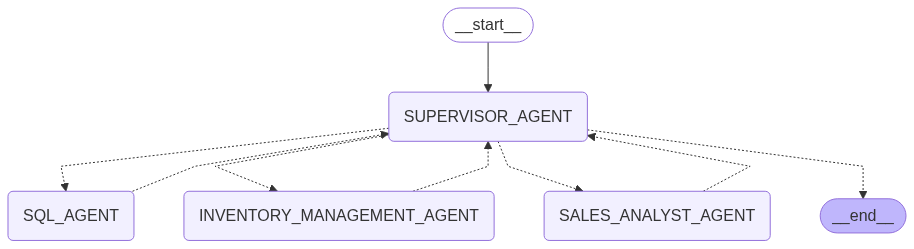

In [94]:
display(Image(multi_agent.get_graph().draw_mermaid_png()))

In [51]:
messages = [
    # HumanMessage(content="What are the top 5 products sold in store S001 during the last day of December 2023?")
    # HumanMessage(content="Can you give me a summary of the sales performance for Store S001 in December 2022")

    # HumanMessage(content="Which product category has the most sales from store s001 in December 2023")
    # HumanMessage(content="What should we restock for the store S001 during the end of February 2022?")
    # HumanMessage(content="What is the top 10 products sold in store S001 during December 2023")
    # HumanMessage(content="What are the total sales for toys category inside store S001 in the month of January 2022?")
    # HumanMessage(
    #     content="What is the restock plan for the store S001 during the end of february 2022?")
    # HumanMessage(content="Generate sales analysis for Store S001 in February 2022")
    # HumanMessage(content="Retrieve monthly sales data for Store S001 for February 2022 and January 2022")
    # HumanMessage(content="Can you help me create the restock plan for Store S001 at the end of February 2022")
    # HumanMessage(
    #     content="Can you help me create the restock plan for Store S001 at the end of February 2022, and also the sales analysis on the same month?")
    # HumanMessage(
    #     content="Help me create restock plan for item named PS5 for February 2022")
    # HumanMessage(
    #     content="Help me create restock plan for store S66 for February 2022")
]
# Invoke the agent
result = multi_agent.invoke({"messages": messages}, {"recursion_limit": 100}, debug=True)
# Print the result
print("\nFinal conversation:")
for m in result["messages"]:
    print(f"{type(m).__name__} ({m.additional_kwargs.get('agent_name', 'unknown')}): {m.content}")
    if hasattr(m, 'tool_calls') and m.tool_calls:
        print(f"Tool calls: {m.tool_calls}")

    print("\n")

[-1:checkpoint] State at the end of step -1:
{}
[0:tasks] Starting 1 task for step 0:
- __start__ -> {'messages': [HumanMessage(content='Can you give me a summary of the sales performance for Store S001 in December 2022', additional_kwargs={}, response_metadata={})]}
[0:writes] Finished step 0 with writes to 1 channel:
- messages -> [HumanMessage(content='Can you give me a summary of the sales performance for Store S001 in December 2022', additional_kwargs={}, response_metadata={})]
[0:checkpoint] State at the end of step 0:
{'messages': [HumanMessage(content='Can you give me a summary of the sales performance for Store S001 in December 2022', additional_kwargs={}, response_metadata={})]}
[1:tasks] Starting 1 task for step 1:
- SUPERVISOR_AGENT -> {'messages': [HumanMessage(content='Can you give me a summary of the sales performance for Store S001 in December 2022', additional_kwargs={}, response_metadata={})]}
🤖 Agent responding: <think>

</think>



 🔧 Calling transfer_to_sales_agent

In [12]:
async def stream_agent_workflow():
    """Stream the agent workflow with real-time updates"""
    messages = [
        HumanMessage(content="hi")]

    print("🚀 Starting multi-agent workflow...\n")

    # Track streaming content for each agent
    agent_streams = {}

    async for event in multi_agent.astream_events(
            {"messages": messages},
            {"recursion_limit": 100},
            version="v1"
    ):
        event_type = event.get("event")
        event_name = event.get("name", "")

        # Agent starts working
        if event_type == "on_chain_start" and "AGENT" in event_name:
            print(f"🤖 {event_name} is starting...")
            # Initialize streaming buffer for this agent
            agent_streams[event_name] = {
                'content': '',
                'tool_calls': [],
                'printed_header': False
            }

        # Agent streams content chunks
        elif event_type == "on_chain_stream" and "AGENT" in event_name:
            chunk = event.get("data", {}).get("chunk")

            if hasattr(chunk, 'update') and 'messages' in chunk.update:
                messages_list = chunk.update['messages']

                # Get the latest AI message
                ai_messages = [msg for msg in messages_list if
                               hasattr(msg, 'content') and msg.additional_kwargs.get('agent_name')]

                if ai_messages:
                    latest_msg = ai_messages[-1]
                    agent_name = latest_msg.additional_kwargs.get('agent_name', 'Unknown')

                    # Initialize agent stream if not exists
                    if agent_name not in agent_streams:
                        agent_streams[agent_name] = {
                            'content': '',
                            'tool_calls': [],
                            'printed_header': False
                        }

                    # Print header only once per agent response
                    if not agent_streams[agent_name]['printed_header']:
                        print(f"📤 {agent_name} responds:")
                        agent_streams[agent_name]['printed_header'] = True

                    # Accumulate content
                    if hasattr(latest_msg, 'content') and latest_msg.content:
                        new_content = latest_msg.content

                        # Only process new content (avoid duplicates)
                        if new_content != agent_streams[agent_name]['content']:
                            agent_streams[agent_name]['content'] = new_content

                            # Handle JSON responses
                            if new_content.startswith('{"') or new_content.startswith('```json'):
                                try:
                                    # Extract JSON from code blocks if present
                                    if new_content.startswith('```json'):
                                        json_start = new_content.find('{')
                                        json_end = new_content.rfind('}') + 1
                                        if json_start != -1 and json_end > json_start:
                                            json_content = new_content[json_start:json_end]
                                        else:
                                            json_content = new_content
                                    else:
                                        json_content = new_content.replace('/no_think', '')

                                    parsed = json.loads(json_content)

                                    status = parsed.get('status', 'N/A')
                                    requested = parsed.get('requested', 'N/A')
                                    data = parsed.get('data', None)

                                    print(f"   Status: {status}")
                                    if requested != 'N/A':
                                        print(f"   Request: {requested}")

                                    # Display data if present
                                    if data:
                                        if isinstance(data, list) and len(data) > 0:
                                            print(f"   Data: Found {len(data)} records")
                                            # Show first few records as preview
                                            for i, record in enumerate(data[:3]):
                                                print(f"     Record {i + 1}: {record}")
                                            if len(data) > 3:
                                                print(f"     ... and {len(data) - 3} more records")
                                        else:
                                            print(f"   Data: {data}")

                                except json.JSONDecodeError as e:
                                    # If JSON parsing fails, show raw content
                                    print(f"   Content: {new_content}")
                                except Exception as e:
                                    print(f"   Content: {new_content}")
                            else:
                                # Handle regular text content
                                print(f"   Content: {new_content}")

                    # Handle tool calls
                    if hasattr(latest_msg, 'tool_calls') and latest_msg.tool_calls:
                        for tool_call in latest_msg.tool_calls:
                            tool_name = tool_call.get('name', 'Unknown')
                            tool_args = tool_call.get('args', {})

                            # Avoid duplicate tool call printing
                            tool_signature = f"{tool_name}_{str(tool_args)}"
                            if tool_signature not in agent_streams[agent_name]['tool_calls']:
                                agent_streams[agent_name]['tool_calls'].append(tool_signature)
                                print(f"   🔧 Calling {tool_name}")
                                if 'instruction' in tool_args:
                                    print(f"      Instruction: {tool_args['instruction']}")
                                if 'query' in tool_args:
                                    print(f"      Query: {tool_args['query']}")

        # Agent completes work
        elif event_type == "on_chain_end" and "AGENT" in event_name:
            if event_name in agent_streams:
                print()  # Add spacing after agent completes
                # Reset for next potential call
                agent_streams[event_name]['printed_header'] = False

    print("✅ Workflow completed!")


# Alternative version that shows real-time streaming character by character
async def stream_agent_workflow_realtime():
    """Stream with real-time character-by-character output"""

    messages = [
        HumanMessage(content="What are the top 10 products sold in store S002 during the first day of January 2022?")]

    print("🚀 Starting multi-agent workflow...\n")

    agent_buffers = {}

    async for event in multi_agent.astream_events(
            {"messages": messages},
            {"recursion_limit": 100},
            version="v1"
    ):
        event_type = event.get("event")
        event_name = event.get("name", "")

        if event_type == "on_chain_start" and "AGENT" in event_name:
            print(f"🤖 {event_name} is starting...")
            agent_buffers[event_name] = ""

        elif event_type == "on_chain_stream" and "AGENT" in event_name:
            chunk = event.get("data", {}).get("chunk")

            if hasattr(chunk, 'update') and 'messages' in chunk.update:
                messages_list = chunk.update['messages']
                ai_messages = [msg for msg in messages_list if
                               hasattr(msg, 'content') and msg.additional_kwargs.get('agent_name')]

                if ai_messages:
                    latest_msg = ai_messages[-1]
                    agent_name = latest_msg.additional_kwargs.get('agent_name', 'Unknown')

                    if hasattr(latest_msg, 'content') and latest_msg.content:
                        new_content = latest_msg.content

                        # Check if this is new content
                        if agent_name not in agent_buffers:
                            agent_buffers[agent_name] = ""

                        if new_content != agent_buffers[agent_name]:
                            # Print only the new characters
                            if len(new_content) > len(agent_buffers[agent_name]):
                                if agent_buffers[agent_name] == "":
                                    print(f"📤 {agent_name}:")

                                new_chars = new_content[len(agent_buffers[agent_name]):]
                                print(new_chars, end='', flush=True)
                                agent_buffers[agent_name] = new_content

        elif event_type == "on_chain_end" and "AGENT" in event_name:
            print("\n")  # New line when agent finishes

    print("✅ Workflow completed!")


await stream_agent_workflow_realtime()

🚀 Starting multi-agent workflow...

🤖 SUPERVISOR_AGENT is starting...
🤖 Agent responding: <think>

</think>



   🔧 Calling transfer_to_sales_agent
      Instruction: Identify the top 10 products sold in store S002 during the first day of January 2022.


🤖 SALES_ANALYST_AGENT is starting...
📤 sales_analyst_agent:
{"status": "waiting_for_sql_agent_response", "requested": "Get units sold and revenue for store S002 on January 1, 2022."}/no_think

🤖 SUPERVISOR_AGENT is starting...


🤖 SQL_AGENT is starting...
📤 sql_agent:
[{"Product_ID": "P0001", "Units_Sold": 104, "Revenue": 95837.56999999999}]

🤖 SUPERVISOR_AGENT is starting...
📤 supervisor_agent:
- correctness_check: no
- issues and suggestions: [The SQL Agent returned data for only one product (P0001) when the query asked for data about store S002 on January 1, 2022. The response should include all products sold at store S002 on that date. Additionally, the SQL response should not include a "Date" field if it's not explicitly requested

In [ ]:
db.run("UPDATE inventory SET Units_Ordered = 0 WHERE Product_ID = 'P0004' AND Date ='2022-01-31';")

In [36]:
db.run(
    """
    SELECT current.Product_ID,
           current.Inventory_Level,
           CAST(avg_data.Average_Units_Sold + 0.9999 AS INTEGER) AS Average_Units_Sold
    FROM
        -- Data from last day of the month (for Inventory_Level)
        (SELECT Product_ID, Inventory_Level
         FROM inventory
         WHERE Store_ID = 'S001' AND Date = '2022-02-28') AS current
JOIN
    -- Average daily Units_Sold for the full previous month
    (SELECT Product_ID, AVG(Units_Sold) AS Average_Units_Sold
     FROM inventory
     WHERE Store_ID = 'S001' AND Date BETWEEN '2022-02-01' AND '2022-02-28'
     GROUP BY Product_ID) AS avg_data
    ON current.Product_ID = avg_data.Product_ID;
    """
)

"[('P0001', 361, 147), ('P0002', 182, 161), ('P0003', 357, 131), ('P0004', 55, 137), ('P0005', 407, 128), ('P0006', 308, 149), ('P0007', 473, 109), ('P0008', 171, 128), ('P0009', 381, 134), ('P0010', 442, 124)]"

In [38]:
db.run("""
       SELECT Product_ID, Units_Sold, (Units_Sold * Price * (1 - Discount / 100)) AS Revenue
       FROM inventory
       WHERE Store_ID = 'S001' AND Date = '2023-12-31'
       ORDER BY Units_Sold DESC LIMIT 5;
       """)

"[('P0011', 267, 18308.457000000002), ('P0007', 181, 12803.939999999999), ('P0015', 164, 5914.332), ('P0004', 158, 10742.736), ('P0017', 156, 7627.932)]"